# Exploratory Data Analysis (EDA)

This notebook prepares the dataset for forecasting and reorder analytics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath("../src"))

from data_processing import (
    load_raw_data,
    clean_and_filter,
    aggregate_daily_demand,
)

## 1. Load Raw Dataset

Only essential columns related to daily demand are extracted.

In [2]:
cols = [
    "order date (DateOrders)",
    "Product Name",
    "Order Item Quantity",
    "Order Status"
]

df = load_raw_data("../data/raw/DataCoSupplyChainDataset.csv", usecols=cols)

df.head()

,order date (DateOrders),Order Item Quantity,Order Status,Product Name
0,1/31/2018 22:56,1,COMPLETE,Smart watch
1,1/13/2018 12:27,1,PENDING,Smart watch
2,1/13/2018 12:06,1,CLOSED,Smart watch
3,1/13/2018 11:45,1,COMPLETE,Smart watch
4,1/13/2018 11:24,1,PENDING_PAYMENT,Smart watch


## 2. Data Cleaning & Filtering

We retain only **fulfilled** orders (COMPLETE, CLOSED)  
because forecasting must model actual customer demand.

Dates are converted to proper datetime format.

In [3]:
df = clean_and_filter(df)

df.head()
df.shape

(79107, 4)

## 3. Aggregate Daily Demand

Convert transaction-level data into:

- **Daily demand**
- **Per product (SKU)**

This prepares the dataset for time-series forecasting.

In [4]:
daily_demand = aggregate_daily_demand(df)

daily_demand.head()
daily_demand.shape

(15497, 3)

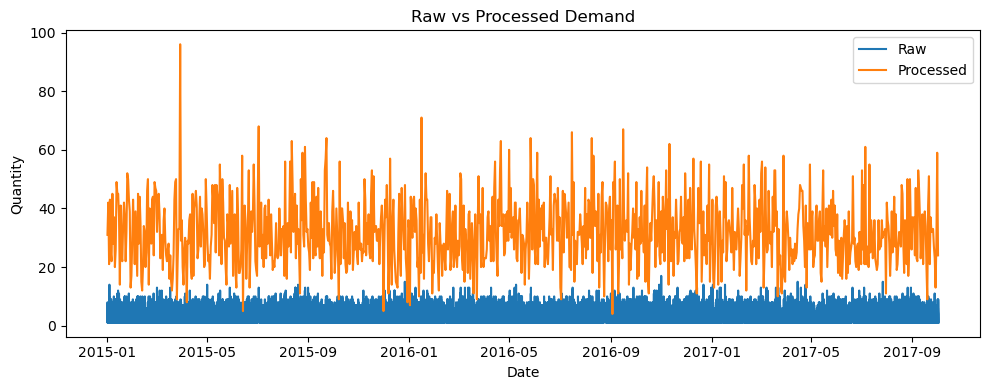

In [5]:
# RAW vs PROCESSED (Image 1)

raw_df = pd.read_csv("../data/raw/DataCoSupplyChainDataset.csv", encoding="latin1")

raw_df["order date (DateOrders)"] = pd.to_datetime(raw_df["order date (DateOrders)"])

sample_product = raw_df["Product Name"].value_counts().index[0]

raw_sample = raw_df[raw_df["Product Name"] == sample_product]
raw_agg = raw_sample.groupby("order date (DateOrders)")["Order Item Quantity"].sum()

processed_sample = daily_demand[daily_demand["Product Name"] == sample_product]
processed_series = processed_sample.set_index("order date (DateOrders)")["Order Item Quantity"]

plt.figure(figsize=(10,4))
plt.plot(raw_agg.index, raw_agg.values, label="Raw")
plt.plot(processed_series.index, processed_series.values, label="Processed")

plt.title("Raw vs Processed Demand")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.legend()
plt.tight_layout()

plt.savefig("../outputs/figures/raw_vs_processed.png")
plt.show()

## 4. Save Processed Dataset

This file is used by the forecasting module.

In [6]:
daily_demand.to_csv("../data/processed/daily_demand.csv", index=False)

## 5. Descriptive Statistics

Understand demand distribution and variability.

In [7]:
daily_demand["Order Item Quantity"].describe()

count    15497.000000
mean        10.846099
std         11.338140
min          1.000000
25%          3.000000
50%          6.000000
75%         15.000000
max         96.000000
Name: Order Item Quantity, dtype: float64

## 6. Demand Trend Visualization (Sample Product)

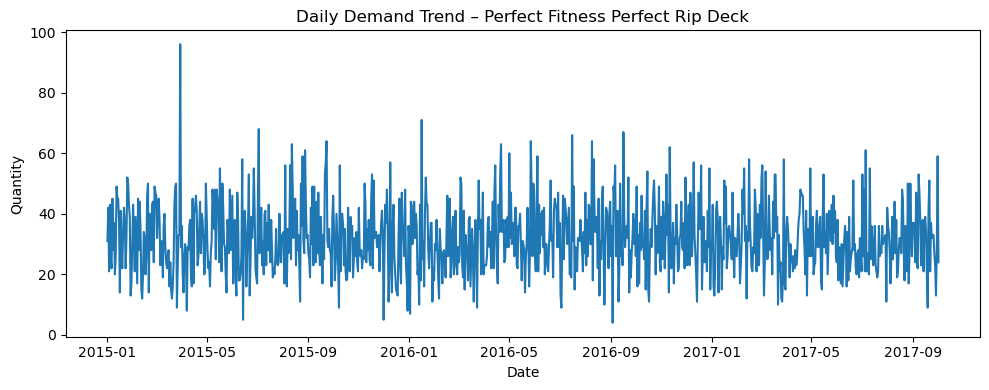

In [8]:
sample_product = daily_demand["Product Name"].value_counts().index[0]
sample_df = daily_demand[daily_demand["Product Name"] == sample_product]

sample_df = sample_df.sort_values("order date (DateOrders)")

plt.figure(figsize=(10,4))
plt.plot(sample_df["order date (DateOrders)"], sample_df["Order Item Quantity"])
plt.title(f"Daily Demand Trend – {sample_product}")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.tight_layout()
plt.savefig("../outputs/figures/demand_trend.png")
plt.show()

## 7. Overall Demand (All Products Combined)

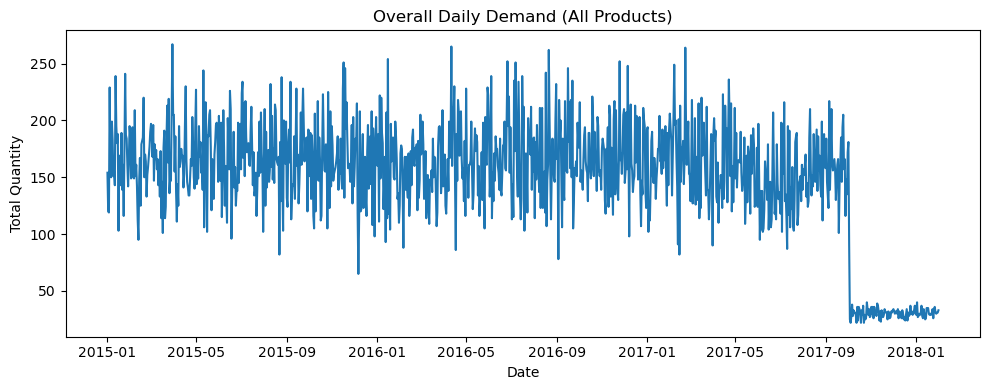

In [9]:
overall_daily = (
    daily_demand.groupby("order date (DateOrders)")["Order Item Quantity"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,4))
plt.plot(overall_daily["order date (DateOrders)"], overall_daily["Order Item Quantity"])
plt.title("Overall Daily Demand (All Products)")
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.tight_layout()
plt.savefig("../outputs/figures/overall_demand.png")
plt.show()

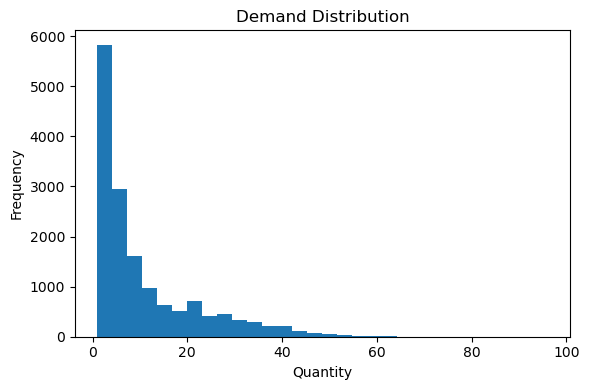

In [10]:
# Histogram (Image)

plt.figure(figsize=(6,4))
plt.hist(daily_demand["Order Item Quantity"], bins=30)

plt.title("Demand Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("../outputs/figures/demand_histogram.png")
plt.show()

C:\Users\jenis\AppData\Local\Temp\ipykernel_18624\3229951926.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


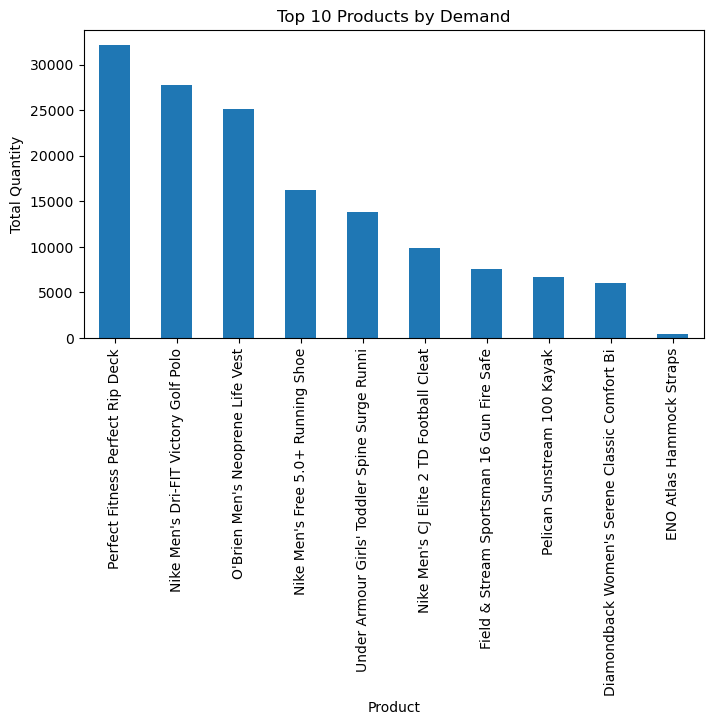

In [11]:
# Top Products (Image)

top_products = (
    daily_demand.groupby("Product Name")["Order Item Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,4))
top_products.plot(kind="bar")

plt.title("Top 10 Products by Demand")
plt.xlabel("Product")
plt.ylabel("Total Quantity")
plt.tight_layout()

plt.savefig("../outputs/figures/top_products.png")
plt.show()

## 8. EDA Insights

- Daily demand varies significantly across time.  
- Zero-demand days exist — typical in wholesale/warehouse operations.  
- Product demand is irregular and non-seasonal.  
- Justifies the selection of ARIMA-based forecasting.
